In [75]:
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt 
import umap

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
cols = ['year','Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL']
categorical_cols = ['Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'VolAny', 'NSSEC5']
path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\exploration_data\master.csv'
df = pd.read_csv(path, usecols=cols)
df = df[df['year'] == '2022 - 2023']
len(df)

16748

In [36]:
df = df.dropna()
len(df)

4266

In [52]:
df['MEMS7_ALL'].describe()

count     4266.000000
mean       813.317569
std       1218.053331
min          0.000000
25%        120.000000
50%        450.000000
75%       1038.750000
max      23962.500000
Name: MEMS7_ALL, dtype: float64

<Axes: >

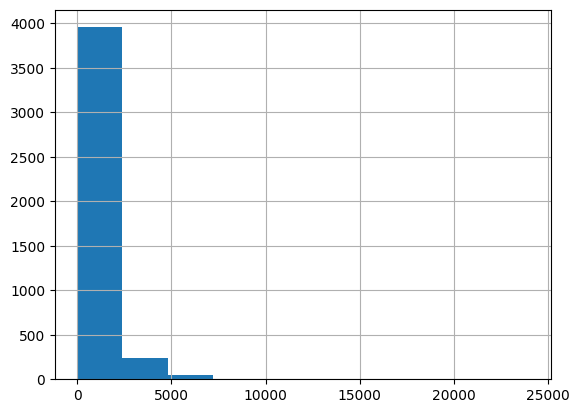

In [53]:
df['MEMS7_ALL'].hist()

In [37]:
exclude_cols = [
    'DURATION_SPORTCOUNT_A01',
    'MEMS7_IN_SPORTCOUNT_A01',
    'MEMS7_OUT_SPORTCOUNT_A01',
    'year'
]
p_cols = []
for i in cols:
    if i in exclude_cols:
        continue
    p_cols.append(i)

print(p_cols)

['Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'MEMS7_ALL']


In [38]:
df = pd.get_dummies(df[p_cols], columns = categorical_cols)
df.head()

,DVBMI,MEMS7_ALL,Gend3_1.0,Gend3_2.0,Gend3_3.0,Disab3_1.0,Disab3_2.0,Disab3_3.0,Age9_2.0,Age9_3.0,...,Eth7_4.0,Eth7_5.0,Eth7_6.0,Eth7_7.0,VolAny_0.0,VolAny_1.0,NSSEC5_1.0,NSSEC5_2.0,NSSEC5_3.0,NSSEC5_4.0
4,29.270718,0.00,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
13,24.196585,240.00,False,True,False,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,True
18,26.209758,0.00,False,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
26,20.343495,1080.00,False,True,False,True,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
28,25.384306,318.75,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False


In [42]:
print(df.values)

[[29.270718309549952 0.0 True ... False True False]
 [24.196585085555554 240.0 False ... False False True]
 [26.209758145330383 0.0 False ... True False False]
 ...
 [20.17757693977515 360.0 False ... True False False]
 [26.040952824758094 1080.0 True ... False False False]
 [26.47210743801653 865.0 True ... False False False]]


In [47]:
scaler = StandardScaler()
X = df.values
X_scaled = scaler.fit_transform(X)
pca = PCA()
emb = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_
print(np.cumsum(exp_var))

[0.0675491  0.12326242 0.17454209 0.22415395 0.26907718 0.3096432
 0.34731047 0.38081475 0.41230768 0.44175369 0.470504   0.49795923
 0.52527583 0.55190658 0.57797727 0.60318299 0.62826107 0.65269156
 0.67672171 0.70041019 0.7237817  0.74671519 0.76882648 0.79077076
 0.81230776 0.8337629  0.8546468  0.87524273 0.89471038 0.91400617
 0.93231453 0.94997638 0.96702657 0.98354747 0.9936149  1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]


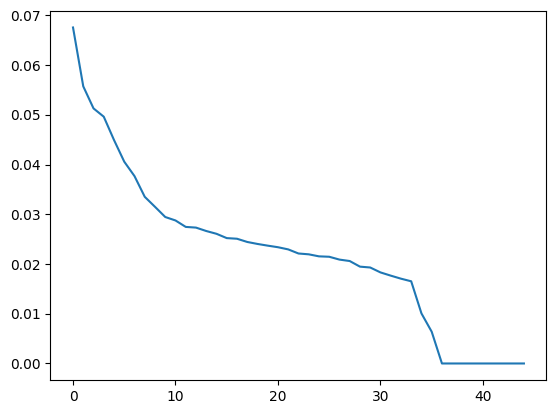

In [48]:
plt.plot(exp_var)

In [51]:
print(exp_var)
pca.components_[:2]

[6.75490977e-02 5.57133200e-02 5.12796753e-02 4.96118553e-02
 4.49232358e-02 4.05660110e-02 3.76672750e-02 3.35042765e-02
 3.14929341e-02 2.94460081e-02 2.87503069e-02 2.74552362e-02
 2.73165936e-02 2.66307563e-02 2.60706884e-02 2.52057223e-02
 2.50780768e-02 2.44304899e-02 2.40301529e-02 2.36884730e-02
 2.33715154e-02 2.29334922e-02 2.21112832e-02 2.19442809e-02
 2.15370021e-02 2.14551440e-02 2.08838956e-02 2.05959286e-02
 1.94676522e-02 1.92957952e-02 1.83083554e-02 1.76618514e-02
 1.70501935e-02 1.65208988e-02 1.00674225e-02 6.38510394e-03
 7.83183359e-17 3.56265063e-17 1.47958957e-17 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


array([[-0.08658932,  0.03960303,  0.09488749, -0.09017366, -0.03784838,
        -0.15500965, -0.02813404,  0.13844128, -0.20623583,  0.16832366,
         0.11945757,  0.004567  , -0.08823544, -0.09504612, -0.15467564,
        -0.00945047,  0.01675048,  0.02099647, -0.09851492, -0.03463106,
        -0.0245156 ,  0.20740173, -0.06209603,  0.0750842 ,  0.01839806,
        -0.01934696,  0.4538933 , -0.23251059, -0.28206825, -0.08209167,
        -0.09730293, -0.14207431,  0.01310978,  0.0781714 , -0.04046765,
        -0.12058776,  0.04928017,  0.00906811, -0.03123371, -0.01916647,
         0.01916647,  0.42732072, -0.23805325, -0.20932678, -0.22612934],
       [-0.09426443, -0.01365275,  0.11200353, -0.10838801, -0.02880199,
        -0.16445019, -0.24319261,  0.31524818,  0.14521873,  0.04010472,
         0.13410912,  0.00356324, -0.14981821, -0.17245898, -0.15975536,
         0.03808518,  0.29126517, -0.04644036,  0.29960855,  0.11891255,
         0.0099837 , -0.16057066,  0.13633859, -0.

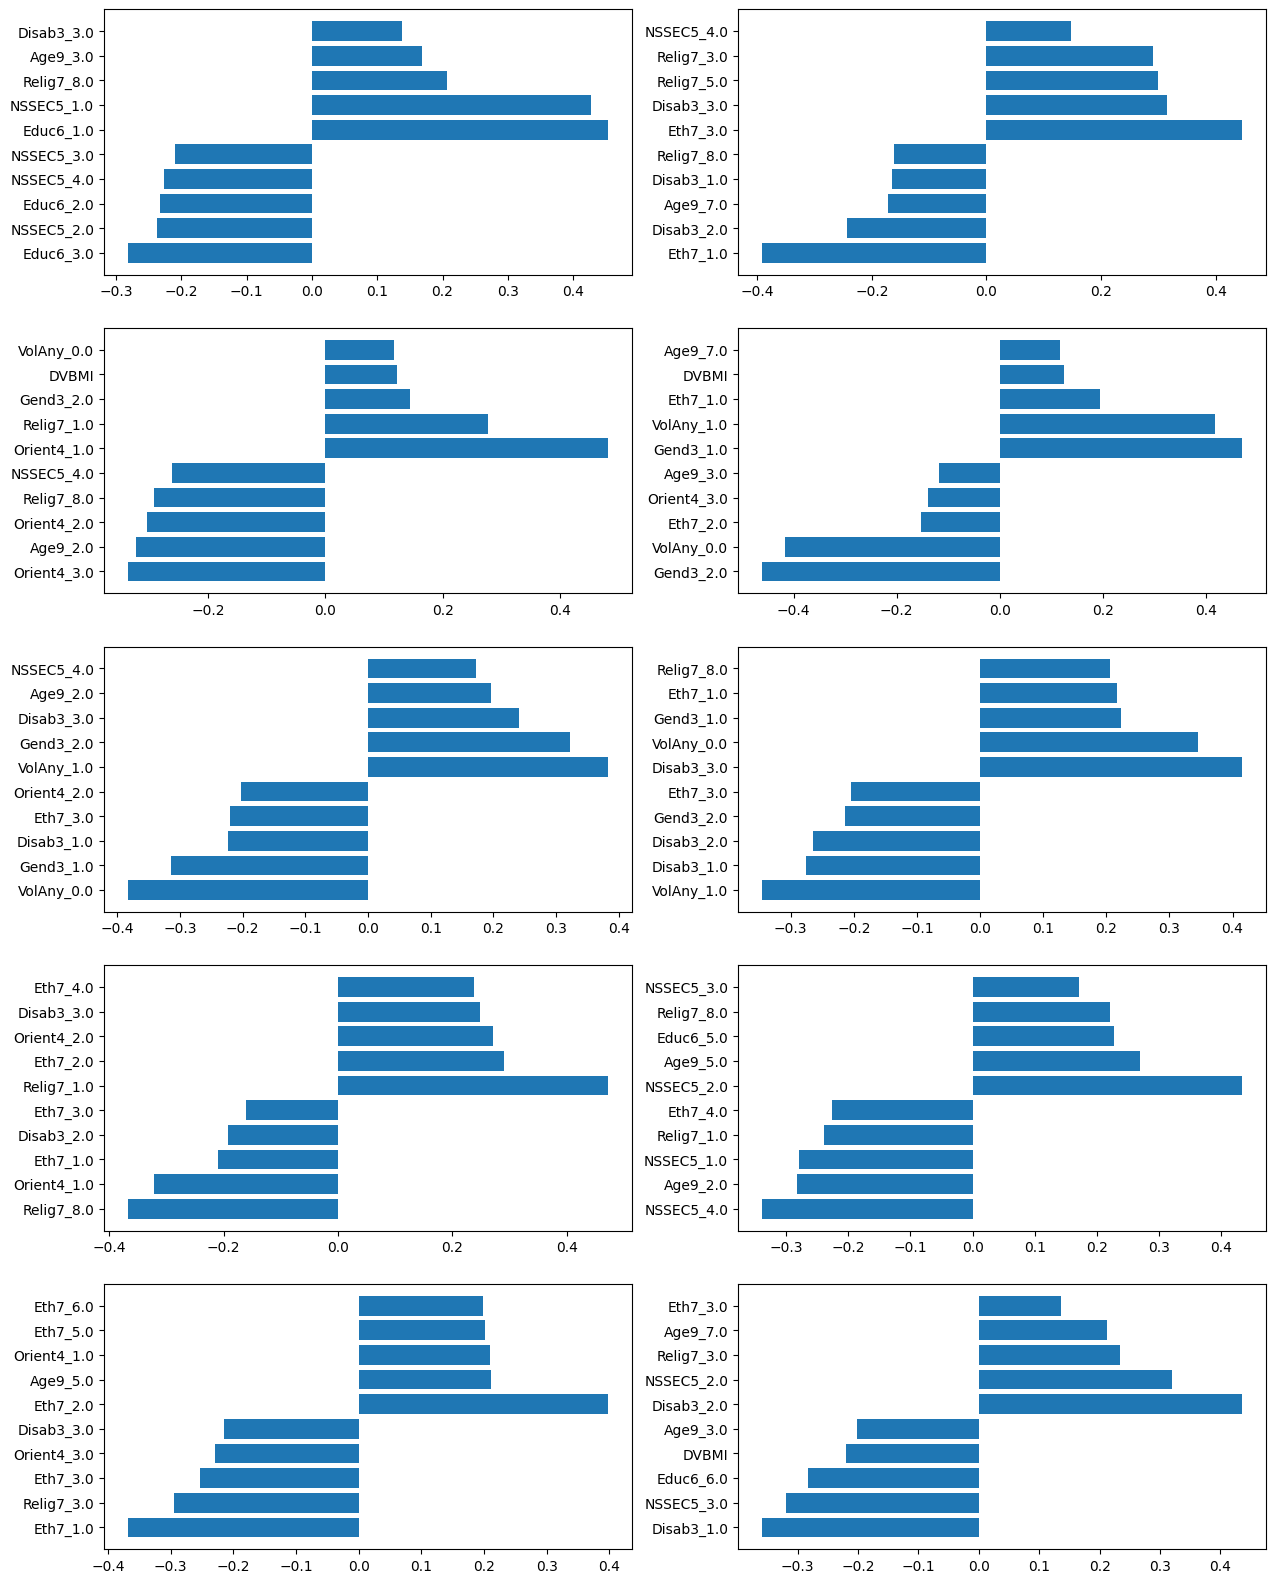

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i in range(10):
    loadings = pd.Series(pca.components_[i], index=df.columns)
    # combined = pd.concat([series.sort_values().head(5), series.sort_values(ascending=False).head(5)])
    combined = pd.concat([loadings.sort_values().head(5), loadings.sort_values(ascending=False).head(5)])
    axes[i].barh(combined.index, combined.values)
  


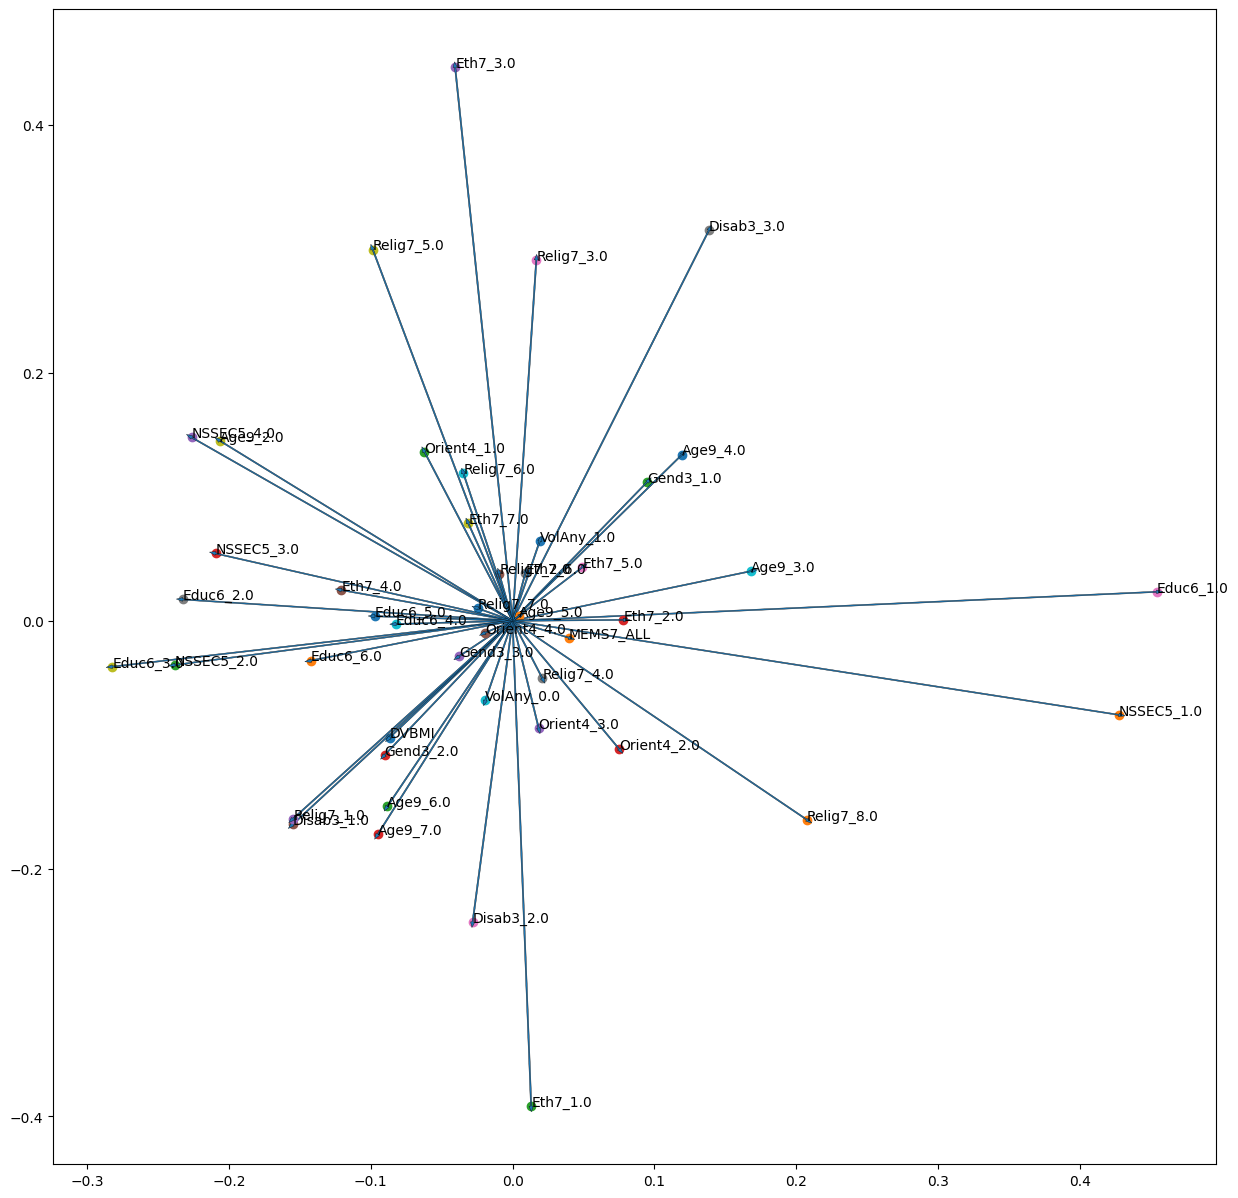

In [66]:
plt.figure(figsize=(15,15))
loadings = pca.components_
xs = loadings[0]
ys = loadings[1]
pca1 = emb[:,0]
pca2 = emb[:,1]
feature_names = df.columns
for i, names in enumerate(feature_names):
    plt.scatter(xs[i], ys[i])
    plt.arrow(
        0, 0, 
        xs[i],
        ys[i],
        linewidth = 0.25
    )
    plt.text(xs[i], ys[i], names)


In [68]:
emb.shape

(4266, 45)

In [72]:
emb.shape[1]

45

In [78]:
pca_df_cols = [f'PCA{i+1}' for i in range(emb.shape[1])]
pca_df = pd.DataFrame(emb, columns = pca_df_cols)
print(pca_df_cols)

['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9', 'PCA10', 'PCA11', 'PCA12', 'PCA13', 'PCA14', 'PCA15', 'PCA16', 'PCA17', 'PCA18', 'PCA19', 'PCA20', 'PCA21', 'PCA22', 'PCA23', 'PCA24', 'PCA25', 'PCA26', 'PCA27', 'PCA28', 'PCA29', 'PCA30', 'PCA31', 'PCA32', 'PCA33', 'PCA34', 'PCA35', 'PCA36', 'PCA37', 'PCA38', 'PCA39', 'PCA40', 'PCA41', 'PCA42', 'PCA43', 'PCA44', 'PCA45']


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


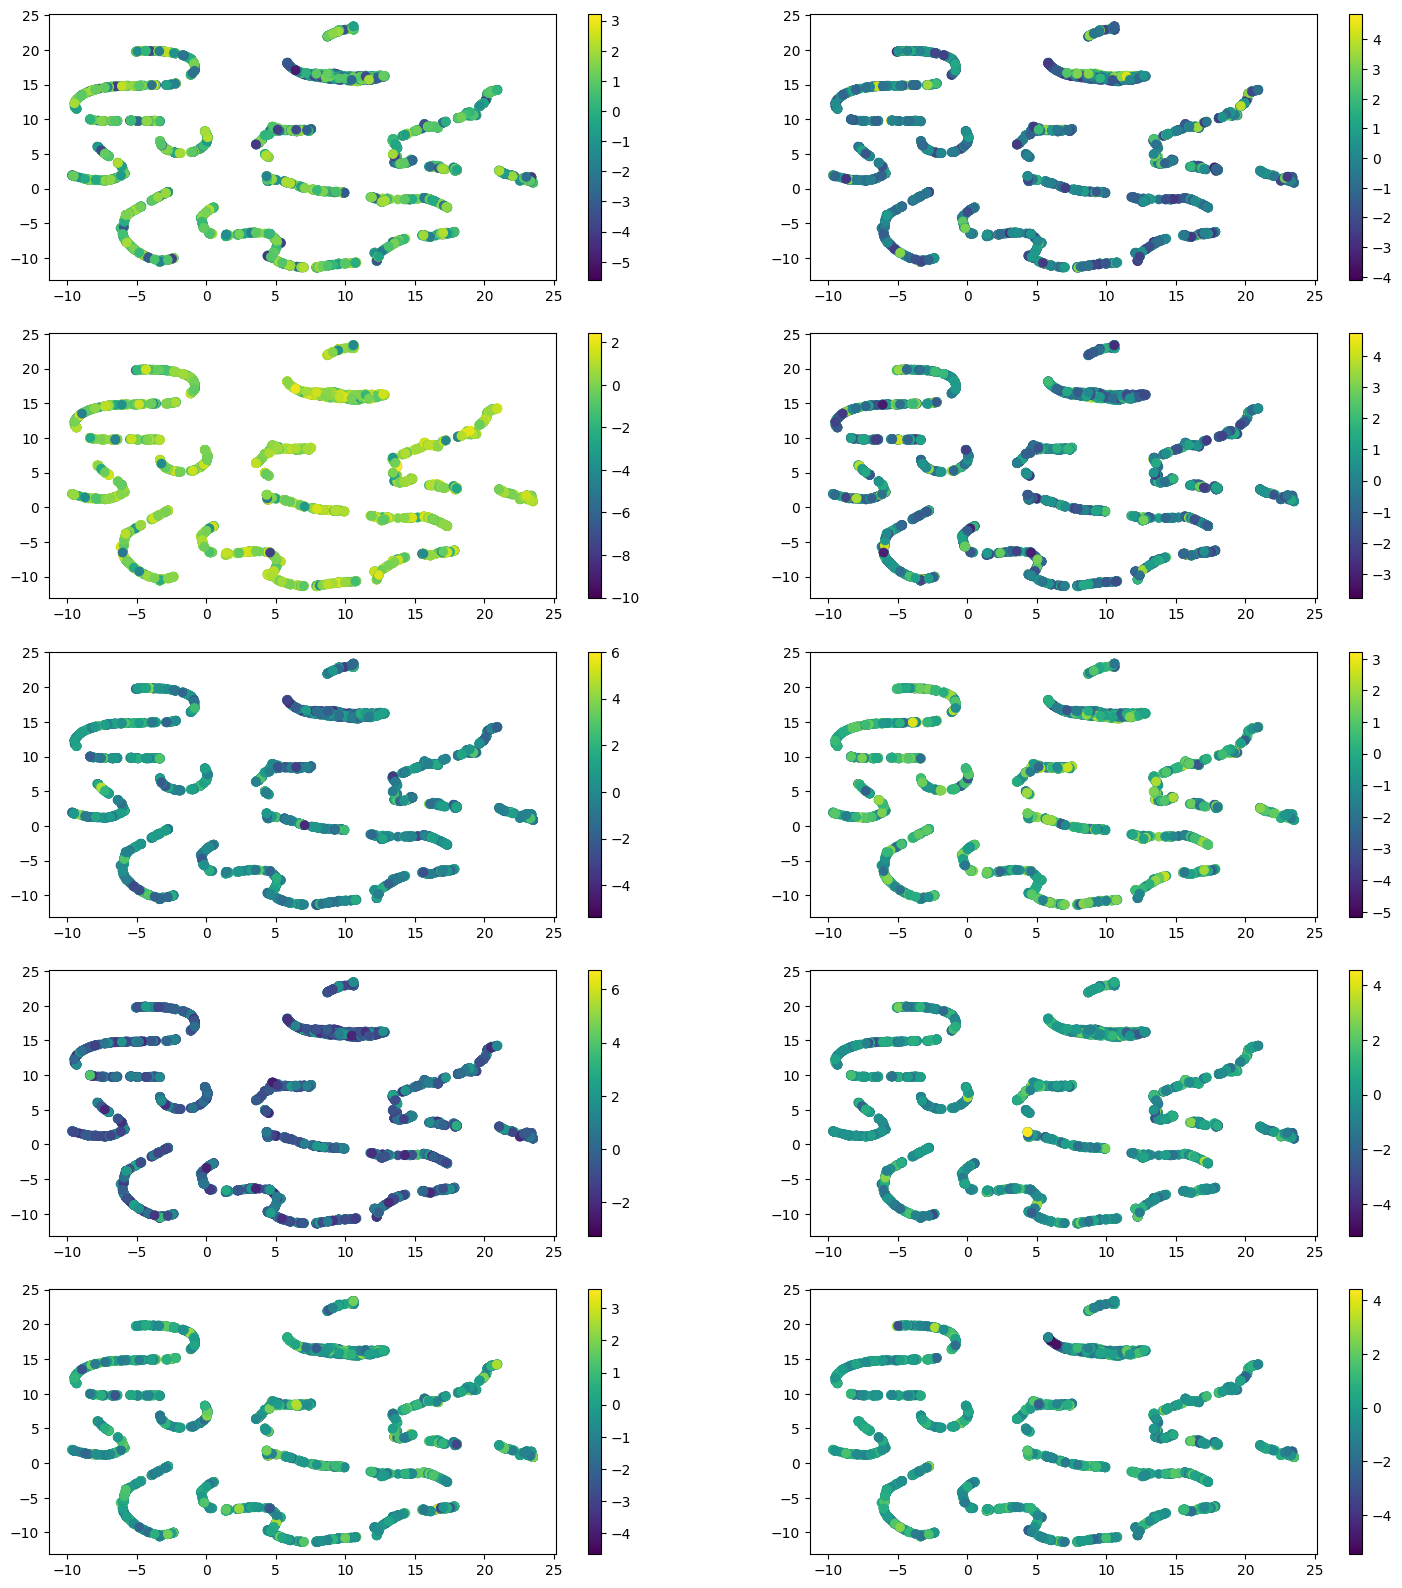

In [82]:
reduce = umap.UMAP(random_state=42)
umap_emb = reduce.fit_transform(df)
fig, axes = plt.subplots(5,2, figsize=(18,20))
axes = axes.flatten()
for i in range(10):
    output = axes[i].scatter(
        umap_emb[:,0], 
        umap_emb[:,1],
        c=pca_df[pca_df_cols[i]]
    )
    plt.colorbar(output, ax=axes[i])